<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/Worksheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.2 Task-1: Implementation of MCP Neurons:


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.Design a MCP Neuron for ”AND” Boolean Functions and ”OR”Boolean Functions with two
inputs:
Hint:
•Aggregate all the inputs.
•Handcraft a Threshold values for ”AND” and ”OR” Function.
•Implement a if else statement as stated above.

AND OPERATION

In [3]:
def MCP_Neurons_AND (X1, X2,T):
  assert len(X1)== len(X2)
  output_neuron =[]
  for i in range(len(X1)):
    z = X1[i] + X2[i]
    if z>=T:
      output_neuron.append(1)
    else:
      output_neuron.append(0)
  return output_neuron


In [4]:
X1 = [0,0,1,1]
X2 = [0,1,0,1]
T = 2
result = MCP_Neurons_AND(X1,X2,T)
print(f"Output of AND gate for inputs{X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs[0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


OR OPERATION

In [5]:
def MCP_Neurons_OR(X1,X2,T):
  output_neuron = []
  for i in range(len(X1)):
     z = X1[i]+X2[i]
     if z>=T:
       output_neuron.append(1)
     else:
       output_neuron.append(0)
  return output_neuron

In [6]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


3.2.1 Answer the Following Question:

Question1:
List out all limitations of MCP - Neurons

Answer:


*   Has a single-layer structure (no hidden layers)


*   Can only solve linearly separable problems

*   Cannot handle non-linearly separable problems like XOR
*   Learning mechanism is absent since weights and threshold are fixed


*   Model works only on binary inputs and outputs and cannot model complex patterns




Question2:
Think if you can develop a logic to solve for XOR function using MCP Neuron.


Answer:

XOR can be implemented using if-else rules where output is 1 when inputs differ and 0 when they are the same, although a single MCP neuron cannot solve it directly.









    


In [7]:
def MCP_Neurons_XOR(X1,X2):
  output_neuron=[]
  for i in range(len(X1)):
    if (X1[i] == 0 and X2[i] ==1) or (X1[i] ==1 and X2[i]==0):
      output_neuron.append(1)
    else:
      output_neuron.append(0)
  return output_neuron



In [8]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
result_xor = MCP_Neurons_XOR(X1, X2)
print(f"Output of XOR gate for inputs {X1} and {X2}: {result_xor}")

Output of XOR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1]: [0, 1, 1, 0]


4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.


2. Load the Dataset:


In [9]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")
df

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12660,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12661,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12662,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12663,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X = df.drop(columns =['label']).values
y = df['label'].values
print("Feature matrix shape:", X.shape)
print("Feature vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Feature vector shape: (12665,)


Answer the Following Question:

1. Question- 1: What does the shape of X represent?

Answer:

Shape of X represent is 2D.X has shape (n_smaples, 784) representing the number of images and 784 pixel features each.



2. Question- 2: What does the shape of X represent?

Answer:

Shape of Y represent is 1D.Y has shape (n_smaples,) holding class labels

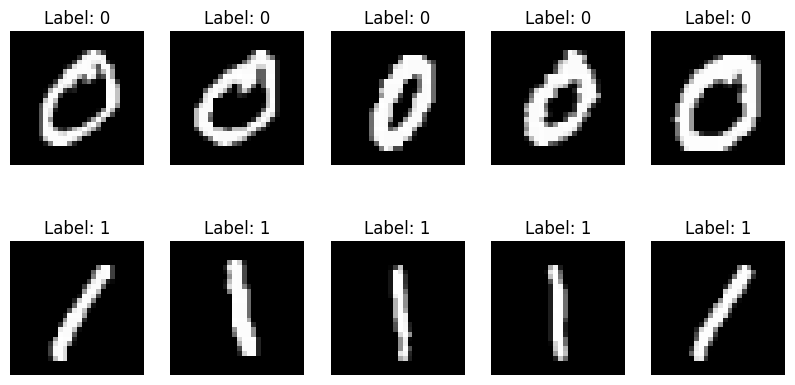

In [11]:
import matplotlib.pyplot as plt
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.show()

3. Initialize Weights and Bias:


In [12]:

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:
1. Question- 3: What does the weights array represent in this context?

Answer: The weight array indicates how important each input feature is for making a prediction. It shows how much influence each feature has on the final output, as the prediction is based on the weighted combination of inputs (X · weights).

2. Question- 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Answer:The weights are initially set to zero since the model has not learned any patterns yet, giving it a neutral starting point. In the case of a perceptron, this does not create issues because the weights are updated uniquely for each training example. As a result, the model is still able to learn effectively during training.

4. Implement a Decision Function or Activation Function:


In [13]:
def decision_function(X,weights, bias):

   predictions = np.dot(X,weights) + bias
   y_pred_all = np.where(predictions>=0 ,1,0)
   return y_pred_all


5. Implement the Perceptron Learning Algorithm:


In [14]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        for i in range(X.shape[0]):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0
            error = y[i] - y_pred

            weights += learning_rate * error * X[i]
            bias += learning_rate * error

    final_pred = decision_function(X, weights, bias)
    accuracy = np.mean(final_pred == y)

    return weights, bias, accuracy

weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print("The training Accuracy is:", accuracy)

The training Accuracy is: 1.0


AnswertheFollowingQuestion:


1. Question- 5: What is the purpose of the output=np.dot(X[i],weights)+ biasline?

Answer: The statement output = np.dot(X[i], weights) + bias calculates the overall input for a given training sample by taking the weighted sum of its features and then adding the bias term. This value represents the raw output of the perceptron before applying the decision rule.





2. Question- 6: What happens when the prediction is wrong? How are the weights and bias updated?

Answer: When the prediction is incorrect, the perceptron updates its weights and bias to correct the error. It adjusts the weights by adding a small value influenced by the error and the input features, and the bias is also modified accordingly. This process helps the model learn from its mistakes and improve its performance over time.





3. Question- 7: Why is the final accuracy important, and what do you expect it to be?

Answer: The final accuracy is important because it indicates how many predictions the perceptron made correctly. If the data is linearly separable, the model can achieve 100% accuracy. If not, the accuracy will be lower, but it still reflects how well the model has learned from the data.

In [15]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:
1. Question- 8:What does misclassified idx store, and how is it used in this code?

Answer: misclassified_idx contains the positions of the training samples that were incorrectly predicted by the model. In the code, it is used to select and display the first 10 misclassified images, along with their predicted and actual labels. This allows us to clearly observe where the model made errors and understand its limitations.

2. Question- 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

Answer: If the output says “All images were correctly classified!”, it indicates that the perceptron has predicted every sample in the dataset without any errors. This means there are no misclassifications, the model has fully learned the data, and the overall accuracy achieved is 100%.

4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.


1. Load Dataset :

In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")
df

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2736,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2737,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2738,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2739,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
X = df.drop(columns=['label']).values / 255.0
y_original = df['label'].values
y = np.where(y_original == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


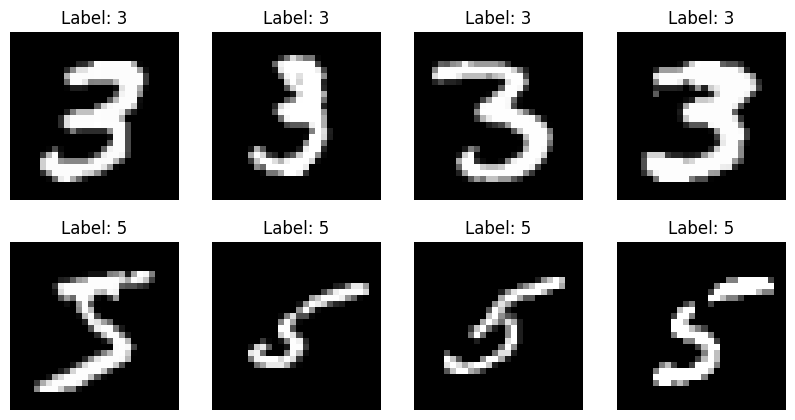

In [18]:
import matplotlib.pyplot as plt

image_3 = X[y_original == 3]
image_5 = X[y_original == 5]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

if len(image_3) < 5 or len(image_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(4):
        # Row 1 → label 3
        axes[0, i].imshow(image_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # Row 2 → label 5
        axes[1, i].imshow(image_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.show()

3. Initialize Weights and Bias:


In [19]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100



4. Implementation of decison fucntion

In [20]:

def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

5.Implement the Perceptron Learning Algorithm

In [21]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        for i in range(X.shape[0]):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0
            error = y[i] - y_pred

            weights += learning_rate * error * X[i]
            bias += learning_rate * error

    final_pred = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.mean(final_pred == y)

    return weights, bias, accuracy

# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("The training Accuracy is:", accuracy)

# Predictions
y_pred = decision_function(X, weights, bias)

# Final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")



The training Accuracy is: 0.9916089018606348
Final Accuracy: 0.9916


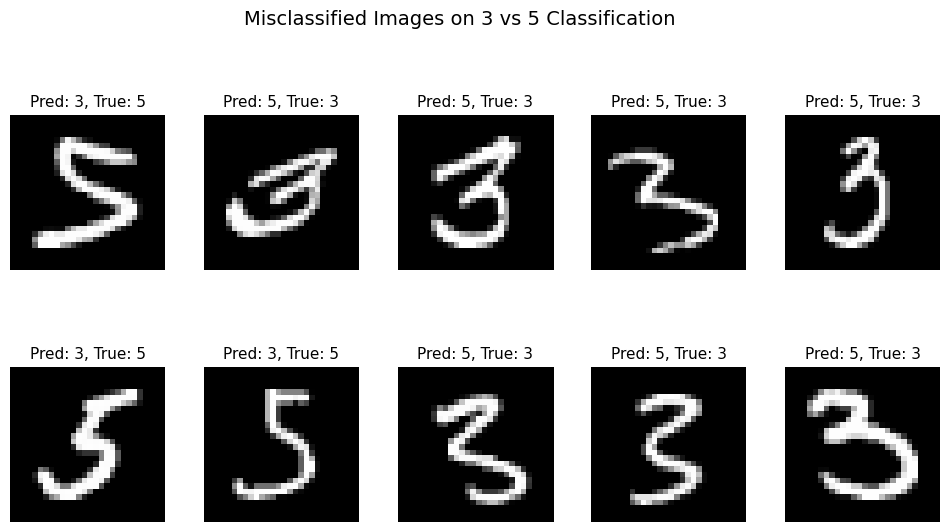

In [24]:
import numpy as np
import matplotlib.pyplot as plt

label_map = {0: 3, 1: 5}   # if your predictions are 0 and 1

misclassified_idx = np.where(y_pred != y)[0]
n_show = min(10, len(misclassified_idx))

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(n_show):
    idx = misclassified_idx[i]
    axes[i].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"Pred: {label_map[y_pred[idx]]}, True: {y_original[idx]}", fontsize=11)
    axes[i].axis("off")

for i in range(n_show, 10):
    axes[i].axis("off")

fig.suptitle("Misclassified Images on 3 vs 5 Classification", fontsize=14)
plt.subplots_adjust(top=0.82, hspace=0.45, wspace=0.25)
plt.show()

Conclusion:
In this task, the Perceptron algorithm was used to classify digits 3 and 5 from the MNIST dataset. After training for 100 epochs, the model was able to correctly predict most of the images. However, some misclassifications still occurred because certain handwritten 3s and 5s look very similar. Compared to simpler cases like 0 vs 1, this makes the problem more challenging. This also demonstrates a limitation of the perceptron, as it can only create a linear decision boundary (a straight line) to separate classes. Since the shapes of 3 and 5 often overlap in terms of curves and strokes, some samples are placed on the wrong side of this boundary. To achieve better performance on such complex data, a more powerful model like a multi-layer neural network would be needed.
